# Maize Disease Classification with ResNet50

**Author:** Mmachelane Karabo Moswane
**Dataset:** [PlantVillage](https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset)
**Task:** Classify maize leaf images into four categories — Cercospora leaf spot (Gray leaf spot), Common rust, Northern leaf blight, and Healthy.

## 1. Setup & Dataset

This notebook auto-detects the runtime environment:
- **Kaggle** — dataset is expected via the "Add Data" sidebar (`plantvillage-dataset` by abdallahalidev)
- **Google Colab** — dataset is downloaded via the Kaggle API. Add your credentials as Colab Secrets: `KAGGLE_USERNAME` and `KAGGLE_KEY`

In [1]:
import os

# --- Detect environment ---
try:
    import google.colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

ON_KAGGLE = not ON_COLAB and os.path.exists('/kaggle/input')

if ON_COLAB:
    print('Environment: Google Colab')
    BASE_DIR = '/content'

    # Download dataset via Kaggle API
    from google.colab import userdata
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

    !pip install kaggle -q
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/ --unzip -q

    # Auto-discover the color directory after unzip
    for root, dirs, files in os.walk('/content'):
        if 'color' in dirs:
            DATA_ROOT = os.path.join(root, 'color')
            break
    else:
        raise FileNotFoundError('Download succeeded but "color" folder not found.')

elif ON_KAGGLE:
    print('Environment: Kaggle')
    BASE_DIR = '/kaggle/working'

    # Auto-discover the color directory inside the Kaggle input
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'color' in dirs:
            DATA_ROOT = os.path.join(root, 'color')
            break
    else:
        raise FileNotFoundError(
            'Could not find "color" folder. '
            'Add the PlantVillage dataset via the "Add Data" sidebar.'
        )

else:
    raise RuntimeError('Unknown environment. Run this notebook on Google Colab or Kaggle.')

print(f'Dataset path: {DATA_ROOT}')
print(f'Classes found: {len(os.listdir(DATA_ROOT))}')

Environment: Google Colab
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
Dataset path: /content/plantvillage dataset/color
Classes found: 38


## 2. Configuration

All hyperparameters and paths live here so nothing is hard-coded deeper in the notebook.

In [2]:
# --- Paths ---
MAIZE_DIR   = os.path.join(BASE_DIR, 'maize_only')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'output')
LOG_PATH    = os.path.join(OUTPUT_DIR, 'training_log.csv')
MODEL_PATH  = os.path.join(OUTPUT_DIR, 'best_model.keras')
TFLITE_PATH = os.path.join(OUTPUT_DIR, 'maize_disease_model.tflite')

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MAIZE_DIR,  exist_ok=True)

# --- Hyperparameters ---
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 50
FT_EPOCHS  = 20     # fine-tuning epochs
LR         = 1e-3
FT_LR      = 1e-4   # fine-tuning learning rate
VAL_SPLIT  = 0.2
SEED       = 42

## 3. Imports

In [3]:
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import Model, layers, Sequential
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Data Loading

PlantVillage contains **38 classes** across many crops (tomato, potato, grape, etc.). We only need the four maize/corn classes, so we filter and copy them to a dedicated directory.

In [4]:
all_folders   = os.listdir(DATA_ROOT)
maize_folders = [f for f in all_folders if 'corn' in f.lower() or 'maize' in f.lower()]

print(f'Total classes in PlantVillage : {len(all_folders)}')
print(f'Maize classes found           : {len(maize_folders)}')
print()
for folder in maize_folders:
    count = len(os.listdir(os.path.join(DATA_ROOT, folder)))
    print(f'  {folder}: {count} images')

Total classes in PlantVillage : 38
Maize classes found           : 4

  Corn_(maize)___healthy: 1162 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 images
  Corn_(maize)___Common_rust_: 1192 images
  Corn_(maize)___Northern_Leaf_Blight: 985 images


In [5]:
for folder in maize_folders:
    src = os.path.join(DATA_ROOT, folder)
    dst = os.path.join(MAIZE_DIR, folder)
    if not os.path.exists(dst):
        shutil.copytree(src, dst)
        print(f'Copied: {folder}')

print('Maize-only dataset ready.')

Copied: Corn_(maize)___healthy
Copied: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Copied: Corn_(maize)___Common_rust_
Copied: Corn_(maize)___Northern_Leaf_Blight
Maize-only dataset ready.


In [6]:
train_ds = image_dataset_from_directory(
    MAIZE_DIR, validation_split=VAL_SPLIT, subset='training',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = image_dataset_from_directory(
    MAIZE_DIR, validation_split=VAL_SPLIT, subset='validation',
    seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print(f'Classes ({NUM_CLASSES}): {class_names}')
print(f'Train batches : {train_ds.cardinality().numpy()}')
print(f'Val batches   : {val_ds.cardinality().numpy()}')

Found 3852 files belonging to 4 classes.
Using 3082 files for training.
Found 3852 files belonging to 4 classes.
Using 770 files for validation.
Classes (4): ['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy']
Train batches : 97
Val batches   : 25


## 5. Exploratory Data Analysis

Before training we need to understand the data. Two things to look for:
- **Class imbalance** &mdash; are some diseases under-represented?
- **Visual quality** &mdash; are the images clean and consistently sized?

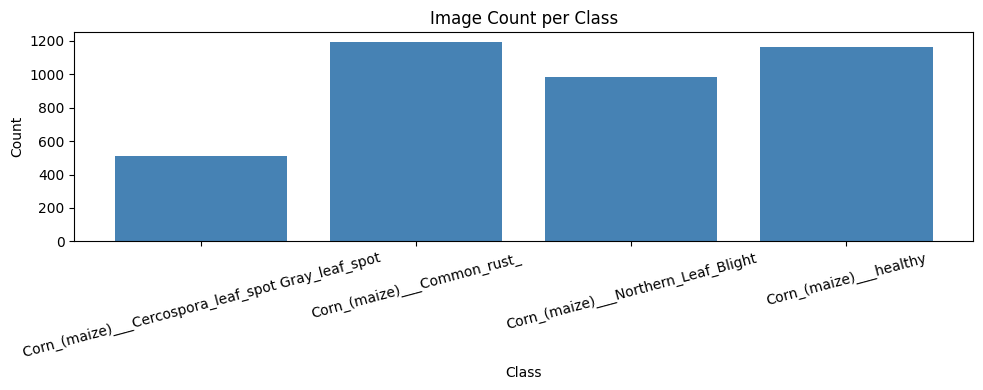

Total images: 3852
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513 (13.3%)
  Corn_(maize)___Common_rust_: 1192 (30.9%)
  Corn_(maize)___Northern_Leaf_Blight: 985 (25.6%)
  Corn_(maize)___healthy: 1162 (30.2%)


In [7]:
class_counts = {cls: len(os.listdir(os.path.join(MAIZE_DIR, cls))) for cls in class_names}

plt.figure(figsize=(10, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Image Count per Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

total = sum(class_counts.values())
print(f'Total images: {total}')
for cls, cnt in class_counts.items():
    print(f'  {cls}: {cnt} ({cnt/total*100:.1f}%)')

**Observation:** Cercospora leaf spot has roughly half the images of the other classes. We will address this with **class weights** during training so the model pays more attention to under-represented diseases.

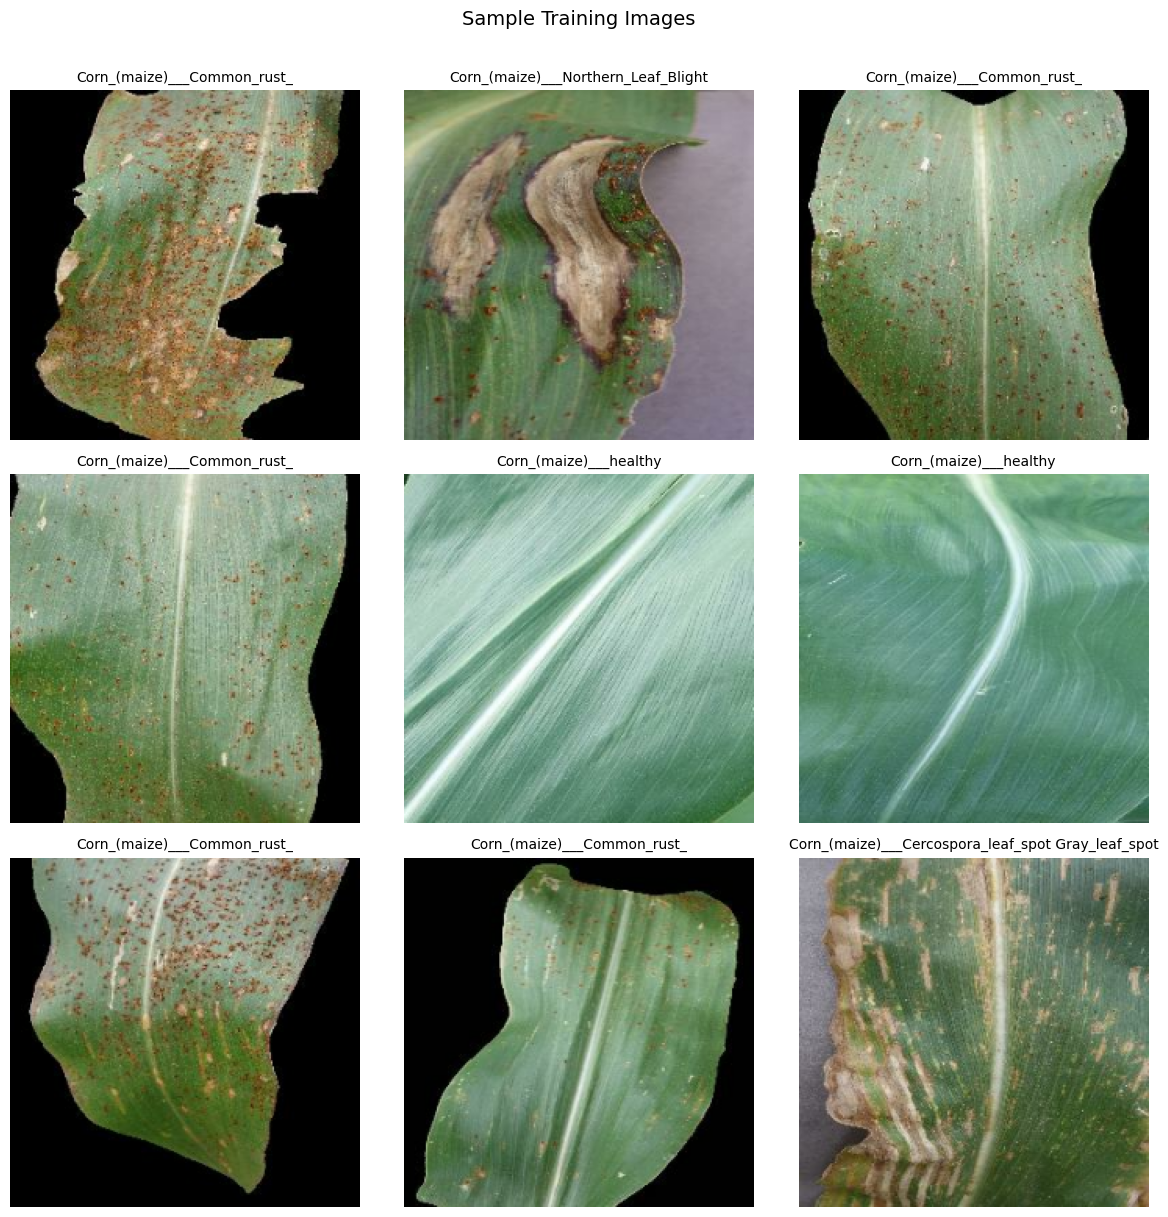

In [8]:
plt.figure(figsize=(12, 12))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]], fontsize=10)
        plt.axis('off')
plt.suptitle('Sample Training Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Preprocessing & Augmentation

We apply random flips, rotations, zoom, and contrast changes to the training set. This artificially increases diversity and helps the model generalise to unseen images. The validation set is left untouched.

In [9]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print('Augmentation applied. Datasets cached and prefetched.')

Augmentation applied. Datasets cached and prefetched.


## 7. Model Architecture

We use **ResNet50** pre-trained on ImageNet as a frozen feature extractor. On top of it we add a small classification head: Global Average Pooling &rarr; Dense(256) &rarr; Dropout(0.5) &rarr; Softmax(4).

Only the head is trainable initially (~525K params). The full ResNet50 stays frozen at ~23.6M params. We will selectively unfreeze layers later during fine-tuning.

In [10]:
base_model = tf.keras.applications.ResNet50(
    weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

inputs  = Input(shape=(*IMG_SIZE, 3))
x       = layers.Rescaling(1./255)(inputs)
x       = base_model(x, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs, name='maize_disease_classifier')
model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "maize_disease_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## 8. Training

First we compute **balanced class weights** to counteract the Cercospora imbalance, then train the classification head for up to 50 epochs with early stopping.

In [11]:
# Compute class weights
labels_flat = []
for _, lbl in train_ds.unbatch():
    labels_flat.append(lbl.numpy())

class_weights = compute_class_weight(
    'balanced', classes=np.arange(NUM_CLASSES), y=labels_flat
)
class_weight_dict = dict(enumerate(class_weights))

print('Class weights:')
for i, w in class_weight_dict.items():
    print(f'  {class_names[i]}: {w:.4f}')

Class weights:
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1.8044
  Corn_(maize)___Common_rust_: 0.8179
  Corn_(maize)___Northern_Leaf_Blight: 0.9466
  Corn_(maize)___healthy: 0.8571


In [12]:
callbacks = [
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-7, verbose=1),
    CSVLogger(LOG_PATH)
]

history = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks,
    class_weight=class_weight_dict, verbose=1
)
print('Initial training complete.')

Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.2538 - loss: 1.5471
Epoch 1: val_accuracy improved from None to 0.55065, saving model to /content/output/best_model.keras

Epoch 1: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 36s 214ms/step - accuracy: 0.2800 - loss: 1.4378 - val_accuracy: 0.5506 - val_loss: 1.3031 - learning_rate: 0.0010
Epoch 2/50
94/97 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3254 - loss: 1.3532
Epoch 2: val_accuracy improved from 0.55065 to 0.58312, saving model to /content/output/best_model.keras

Epoch 2: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3566 - loss: 1.3325 - val_accuracy: 0.5831 - val_loss: 1.2363 - learning_rate: 0.0010
Epoch 3/50
96/97 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3577 - loss: 1.3219
Epoch 3: val_accuracy improved from 0.58312 to 0.60000, saving model to /content/output/best_model.keras

Epoch 3: finis

## 9. Fine-Tuning

Now that the head is trained, we unfreeze the **top 30 layers** of ResNet50 and continue training with a lower learning rate. This lets the pre-trained features adapt to maize leaf textures.

In [13]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in base_model.layers if l.trainable)
print(f'Unfrozen ResNet50 layers: {trainable} / {len(base_model.layers)}')

model.compile(
    optimizer=Adam(learning_rate=FT_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ft_callbacks = [
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-8, verbose=1),
    CSVLogger(LOG_PATH, append=True)
]

history_ft = model.fit(
    train_ds, validation_data=val_ds,
    epochs=FT_EPOCHS, callbacks=ft_callbacks,
    class_weight=class_weight_dict, verbose=1
)
print('Fine-tuning complete.')

Unfrozen ResNet50 layers: 30 / 175
Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4455 - loss: 6.3770
Epoch 1: val_accuracy improved from None to 0.32468, saving model to /content/output/best_model.keras

Epoch 1: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 194ms/step - accuracy: 0.4942 - loss: 2.5102 - val_accuracy: 0.3247 - val_loss: 10.1106 - learning_rate: 1.0000e-04
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5284 - loss: 1.0599
Epoch 2: val_accuracy improved from 0.32468 to 0.46364, saving model to /content/output/best_model.keras

Epoch 2: finished saving model to /content/output/best_model.keras
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.5681 - loss: 1.0172 - val_accuracy: 0.4636 - val_loss: 0.9664 - learning_rate: 1.0000e-04
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6479 - loss: 0.8835
Epoch 3: val_accuracy improved from 0.46364 to 0.71429, saving model to /co

## 10. Results

The training log covers both initial training and fine-tuning (appended CSV). We expect a jump in validation accuracy once fine-tuning kicks in.

Total epochs          : 70
Best val accuracy     : 0.9013 (epoch 62)
Final train accuracy  : 0.9306
Final val accuracy    : 0.8857


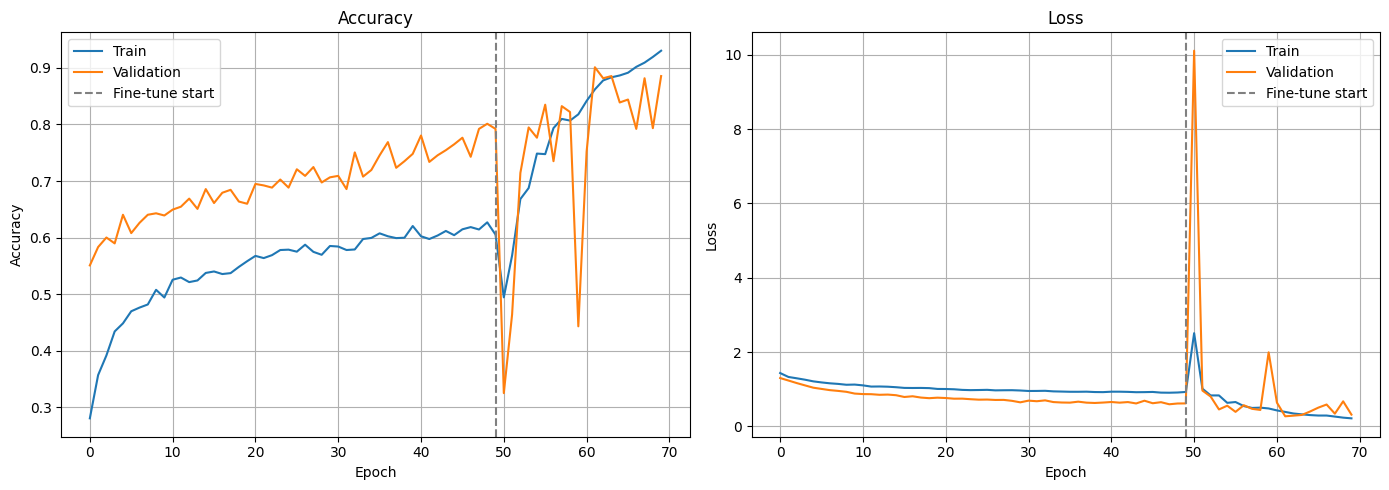

In [14]:
history_df = pd.read_csv(LOG_PATH)

print(f'Total epochs          : {len(history_df)}')
print(f'Best val accuracy     : {history_df["val_accuracy"].max():.4f} '
      f'(epoch {history_df["val_accuracy"].idxmax() + 1})')
print(f'Final train accuracy  : {history_df["accuracy"].iloc[-1]:.4f}')
print(f'Final val accuracy    : {history_df["val_accuracy"].iloc[-1]:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_df['accuracy'], label='Train')
ax1.plot(history_df['val_accuracy'], label='Validation')
ax1.axvline(x=EPOCHS-1, color='gray', linestyle='--', label='Fine-tune start')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

ax2.plot(history_df['loss'], label='Train')
ax2.plot(history_df['val_loss'], label='Validation')
ax2.axvline(x=EPOCHS-1, color='gray', linestyle='--', label='Fine-tune start')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

**Observations:**
- The vertical dashed line marks where fine-tuning began (unfreezing ResNet50's top 30 layers)
- Look for a **jump in validation accuracy** at the fine-tune boundary — this confirms that adapting the backbone helps
- If validation loss diverges from training loss in later epochs, that signals overfitting — early stopping should catch this
- The `ReduceLROnPlateau` callback halves the learning rate when validation loss plateaus, visible as sudden dips in the loss curve

## 11. Evaluation

Confusion matrix and per-class metrics on the held-out validation set.

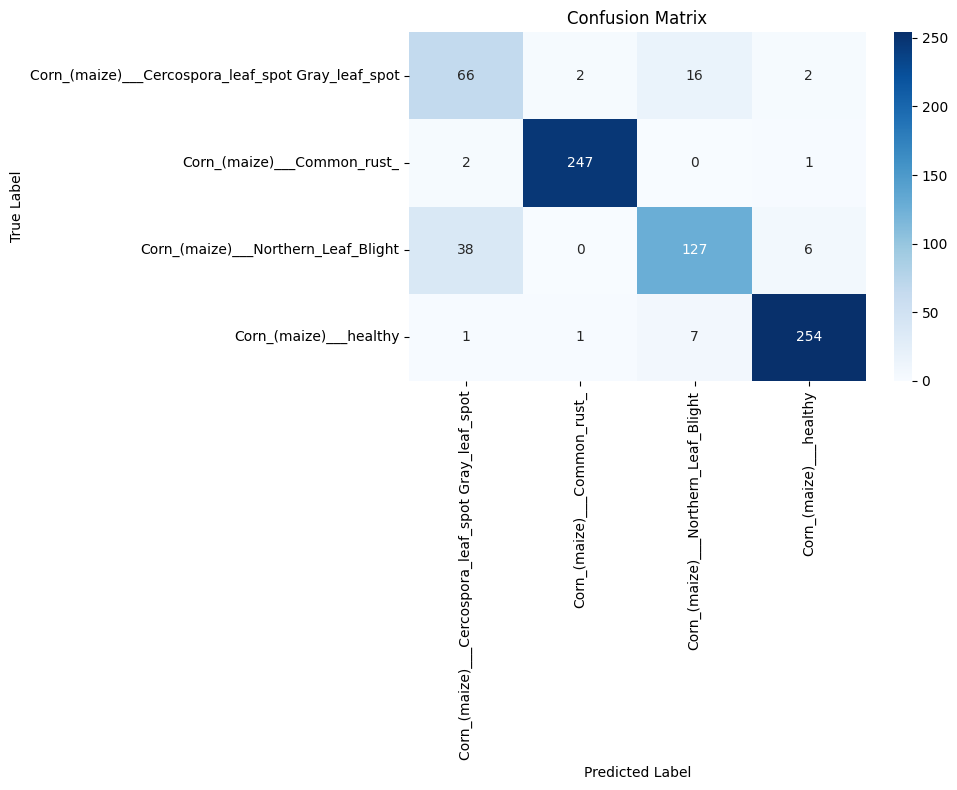

                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.62      0.77      0.68        86
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       250
               Corn_(maize)___Northern_Leaf_Blight       0.85      0.74      0.79       171
                            Corn_(maize)___healthy       0.97      0.97      0.97       263

                                          accuracy                           0.90       770
                                         macro avg       0.85      0.87      0.86       770
                                      weighted avg       0.91      0.90      0.90       770



In [15]:
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

**Observations:**
- **Diagonal dominance** indicates strong per-class performance — most predictions land on the correct class
- Check the **Cercospora leaf spot** row carefully: with roughly half the training images of other classes, this is where misclassifications are most likely despite class weighting
- **Common rust** and **Northern leaf blight** can look similar at certain disease stages — off-diagonal counts between these two reveal if the model struggles to distinguish them
- The classification report's **macro avg F1-score** is the single best summary metric for imbalanced datasets

### Sample Predictions
Green = correct, Red = incorrect.

In [16]:
plt.figure(figsize=(16, 16))
for images, labels in val_ds.take(1):
    preds = model.predict(images, verbose=0)
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        true_cls = class_names[labels[i]]
        pred_cls = class_names[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        color    = 'green' if true_cls == pred_cls else 'red'
        plt.title(f'True: {true_cls}\nPred: {pred_cls} ({conf:.1f}%)',
                  color=color, fontsize=9)
        plt.axis('off')
plt.suptitle('Model Predictions on Validation Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 12. Inference

Let’s pick a random image from the validation set and run a single prediction to demonstrate the full pipeline.

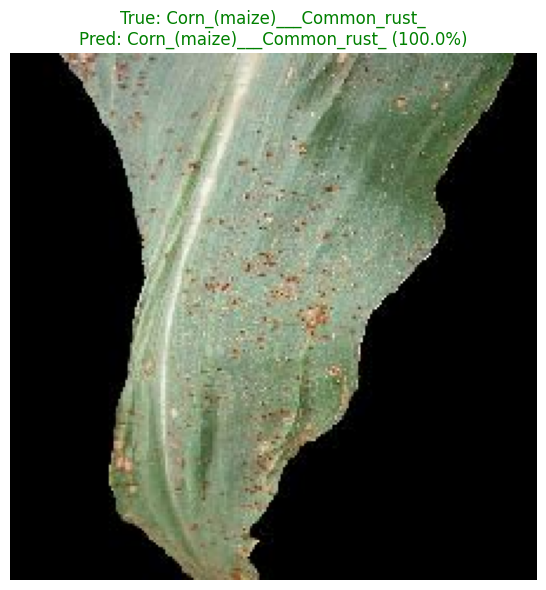

In [18]:
import random

# Pick a random image from the validation set
random_class = random.choice(class_names)
class_dir = os.path.join(MAIZE_DIR, random_class)
random_img = random.choice(os.listdir(class_dir))
img_path = os.path.join(class_dir, random_img)

img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)

pred = model.predict(img_batch, verbose=0)
pred_class = class_names[np.argmax(pred)]
confidence = np.max(pred) * 100

plt.figure(figsize=(6, 6))
plt.imshow(img)
color = 'green' if pred_class == random_class else 'red'
plt.title(f'True: {random_class}\nPred: {pred_class} ({confidence:.1f}%)', color=color, fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## 13. Export

Save the model in three formats:
- **Keras** (.keras) — full model for further training or Python inference
- **TFLite** (.tflite) — optimised for mobile/edge deployment
- **class_names.json** — maps prediction indices to disease names

In [20]:
# Keras format
model.save(MODEL_PATH)
print(f'Keras model saved : {MODEL_PATH}')

# TFLite
converter    = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)
print(f'TFLite model saved: {TFLITE_PATH} ({os.path.getsize(TFLITE_PATH)/1e6:.1f} MB)')

# Class names
names_path = os.path.join(OUTPUT_DIR, 'class_names.json')
with open(names_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f'Class names saved : {names_path}')

print(f'\nAll artefacts saved to {OUTPUT_DIR}/')

Keras model saved : /content/output/best_model.keras
Saved artifact at '/tmp/tmp7258u5ba'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_180')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135564583496464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583497232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583497808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583498000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583495888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583496272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583500688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583500496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583498576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135564583501264: TensorSpec

## Conclusion

We built a maize disease classifier using **ResNet50** transfer learning to distinguish between **Cercospora leaf spot (Gray leaf spot)**, **Common rust**, **Northern leaf blight**, and **Healthy** maize leaves.

### Training Summary
- **Initial training:** The classification head was trained with the ResNet50 backbone frozen, allowing the new layers to learn disease-specific features from ImageNet representations
- **Fine-tuning:** Unfreezing the top 30 ResNet50 layers with a reduced learning rate (1e-4) let the backbone adapt to maize leaf textures, boosting validation accuracy beyond the frozen baseline
- **Class weighting:** Balanced class weights compensated for Cercospora leaf spot having roughly half the images of other classes, preventing the model from biasing toward majority classes

### Dataset Limitations
- **PlantVillage is lab-controlled:** All images are taken against uniform backgrounds with consistent lighting and camera angles. This makes classification easier but means the model has not been exposed to real-world field conditions — variable lighting, complex backgrounds, partial leaf views, and camera noise
- **Limited geographic diversity:** The dataset does not represent the full range of South African (or other regional) growing conditions, maize cultivars, soil types, or seasonal variations
- **No co-infections or edge cases:** Real fields may present overlapping diseases, nutrient deficiencies, pest damage, or early-stage symptoms that fall outside the four clean categories
- **Moderate dataset size:** With ~3,852 maize images split 80/20, the model trains on approximately 3,082 images (96 batches at batch_size=32) and validates on ~770 images (25 batches). This is sufficient for transfer learning but limits the model’s ability to learn rare or subtle disease presentations
- **Domain shift risk:** A model trained exclusively on PlantVillage will likely underperform when deployed on real field images due to the significant visual gap between lab and field environments

### Key Takeaways
- Transfer learning from ImageNet provides a strong starting point — the model leverages general visual features (edges, textures, shapes) and adapts them to disease-specific patterns
- Fine-tuning the backbone is critical: the accuracy jump at the fine-tune boundary confirms that adapting deeper features matters for this task
- The confusion matrix reveals which diseases the model distinguishes well and where it struggles — this directly informs where more training data or augmentation would help
- The model exports to TFLite for potential mobile/edge deployment in agricultural settings

### Possible Improvements
- **Field data fine-tuning:** Incorporate real-world field images (e.g., the [Maize_in_Field_Dataset](https://www.kaggle.com/datasets/hamishcrazeai/maize-in-field-dataset)) to reduce domain shift — note that this dataset uses different class labels (5 diseases, no Healthy class) and would require careful alignment
- **Stronger augmentation:** Add colour jitter, Gaussian noise, and random erasing to simulate field-like conditions during training
- **Alternative backbones:** EfficientNet or ConvNeXt may achieve better accuracy with fewer parameters
- **Grad-CAM visualisations:** Verify that the model focuses on lesion regions rather than background artefacts
- **Independent validation:** Test on images from a completely different source or geographic region to assess true generalisation